In [4]:
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython import display
import matplotlib.pyplot as plt

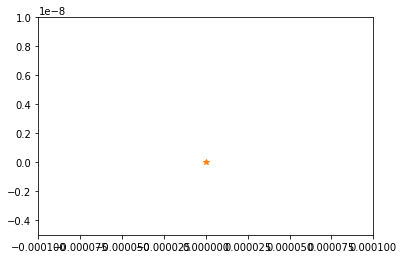

In [5]:
fig, ax = plt.subplots()
lines_plotted = plt.plot([])  
line_plotted = lines_plotted[0]
plt.xlim(-0.0001, 0.0001)
plt.ylim(-0.5e-8, 1e-8)
x = np.linspace(-0.0001,0.0001,100) 
y = 0
marker, = plt.plot([0.],[0.], marker = "*")

In [6]:
r = 2
s = 1
A = 25
B = 0.1264911064
m = 0.8
M = 0.001

In [7]:
f3 = open("runlog", "r")
steps3, a3, phi3, dphi3, starpower = [], [], [], [], []
f3.readline()
f3.readline()
for line in f3.readlines():
    fields = line.split()
    steps3.append( float(fields[0]))
    a3.append(     float(fields[3]))
    phi3.append(   float(fields[7])) # N.B. For new runlogs, phi and dphi are 7 and 8 resp., since I've added e-folds to the output.
    dphi3.append(  float(fields[8]))
    starpower.append(np.power(a3[-1],2.*r- 2.*s)*(A*A/(B*B))*(m*m*M*M)*(np.power( (1. + phi3[-1]*phi3[-1]) , 0.5) - 1.))
f3.close()

In [12]:
def AnimationFunction(frame):
 
    y    = np.power(a3[frame],2.*r- 2.*s)*(A*A/(B*B))*(m*m*M*M)*(np.power( (1. + x*x) , 0.5) - 1.)
    #y    = (A*A/(B*B))*(m*m*M*M)*(np.power( (1. + x*x) , 0.5) - 1.)
    
    star = np.power(a3[frame],2.*r- 2.*s)*(A*A/(B*B))*(m*m*M*M)*(np.power( (1. + phi3[frame]*phi3[frame]) , 0.5) - 1.)
    #star = (A*A/(B*B))*(m*m*M*M)*(np.power( (1. + phi3[frame]*phi3[frame]) , 0.5) - 1.)
 
    # line is set with new values of x and y
    line_plotted.set_data((x, y))
    marker.set_data(phi3[frame],star)

In [13]:
anim_created = FuncAnimation(fig, AnimationFunction, frames=6000, interval=5)

In [14]:
video = anim_created.to_html5_video()
html = display.HTML(video)
display.display(html)

In [11]:
#plt.plot(phi3, starpower)